# DiffDock vs SigmaDock — Calibration Comparison (PoseBusters)

Compares **pose distribution calibration** of DiffDock (40 samples, confidence-ranked)
against SigmaDock under four conditions (ODE-25, SDE-10, SDE-25, SDE-50; 40 seeds each,
heuristic-ranked) using:

- **TARP** (symRMSD, K=10): ECP curves; diagonal = perfect calibration
- **MIRA** (symRMSD, num_runs=100): scalar per-complex; `mira_null(40) ≈ 0.683` = perfect
- **Group TARP / MIRA** (K=100 / num_runs=100): broken down by Translation / Rotation / Torsion DOF
- **Top-1 RMSD accuracy**: fraction of complexes where rank-1 pose has RMSD < 2 Å

Cells degrade gracefully if a file is not yet available.

In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

from molcalib.tarp import ecp_from_fractions, bootstrap_ecp, plot_ecp
from molcalib.mira import mira_null

S         = 40
MIRA_NULL = mira_null(S)
N_BOOT    = 200
GROUPS    = ['translation', 'rotation', 'torsion']
GROUP_LABELS = {
    'translation': 'Translation (R³)',
    'rotation':    'Rotation (SO(3))',
    'torsion':     'Torsion (T^k)',
}

print(f'MIRA null (S={S}): {MIRA_NULL:.4f}')

MIRA null (S=40): 0.6833


## 1. Paths & conditions

In [2]:
SD_BASE = '/home/qf226/rds/hpc-work/results/SigmaDock/sigmadock_pb_sde/results/posebusters'
DD_BASE = '/home/qf226/rds/hpc-work/results/DiffDock/sensitivity_ode_nsteps_v3'

FIGDIR = os.path.abspath('../figures/comparison_diffdock_sigmadock')
os.makedirs(FIGDIR, exist_ok=True)

# SigmaDock condition → matched DiffDock subdir
DD_MATCH = {
    'ode_25':  'ode_20',
    'steps10': 'sde_10',
    'steps25': 'sde_20',
    'steps50': 'sde_50',
}

CONDITIONS = {
    'ode_25':  {'label': 'SigmaDock ODE-25', 'dd_label': 'DiffDock ODE-20', 'color': '#4CAF50'},
    'steps10': {'label': 'SigmaDock SDE-10', 'dd_label': 'DiffDock SDE-10', 'color': '#2196F3'},
    'steps25': {'label': 'SigmaDock SDE-25', 'dd_label': 'DiffDock SDE-20', 'color': '#9C27B0'},
    'steps50': {'label': 'SigmaDock SDE-50', 'dd_label': 'DiffDock SDE-50', 'color': '#FF9800'},
}
DD_LS = '--'

## 2. Load data

In [3]:
def _npy(path):
    return np.load(path, allow_pickle=True) if os.path.exists(path) else None

def _npz_key(path, key):
    if not os.path.exists(path):
        return None
    d = np.load(path, allow_pickle=True)
    return d[key] if key in d else None

def _json(path):
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

# ── SigmaDock ──────────────────────────────────────────────────────────────
sd = {}
for cond in CONDITIONS:
    m   = f'{SD_BASE}/{cond}/metrics'
    ge  = f'{m}/group_eval'
    d = {
        'mira_scores': _npy(f'{m}/mira_scores_symrmsd.npy'),
        'tarp_f':      _npy(f'{m}/tarp_fractions_symrmsd_K10.npy'),
        'top1_rmsd':   _npy(f'{m}/top1_rmsd.npy'),
        'pb_json':     _json(f'{m}/posebusters_results_pb.json'),
    }
    for g in GROUPS:
        d[f'tarp_{g}'] = _npy(f'{ge}/tarp_fractions_{g}.npy')
        d[f'mira_{g}'] = _npy(f'{ge}/mira_scores_{g}.npy')
    sd[cond] = d

# ── DiffDock (matched per condition) ────────────────────────────────────────
dd = {}
for cond, dd_cond in DD_MATCH.items():
    m  = f'{DD_BASE}/{dd_cond}/metrics'
    ge = f'{m}/group_eval'
    d = {
        'mira_scores': _npy(f'{m}/mira_scores_symrmsd.npy'),
        'tarp_f':      _npy(f'{m}/tarp_fractions_symrmsd_K10.npy'),
        'tarp_K1':     _npy(f'{m}/tarp_fractions_symrmsd_K1.npy'),
        'top1_rmsd':   _npy(f'{m}/top1_rmsd.npy'),
        'pb_json':     None,
    }
    for g in GROUPS:
        d[f'tarp_{g}'] = _npy(f'{ge}/tarp_fractions_{g}.npy')
        d[f'mira_{g}'] = _npy(f'{ge}/mira_scores_{g}.npy')
    dd[cond] = d

In [4]:
def _r(x): return '✓' if x is not None else '–'

keys = [
    ('tarp_f (K=10)',    'tarp_f'),
    ('mira_scores',      'mira_scores'),
    ('top1_rmsd',        'top1_rmsd'),
    ('pb_json',          'pb_json'),
    ('tarp_translation', 'tarp_translation'),
    ('tarp_rotation',    'tarp_rotation'),
    ('tarp_torsion',     'tarp_torsion'),
    ('mira_translation', 'mira_translation'),
    ('mira_rotation',    'mira_rotation'),
    ('mira_torsion',     'mira_torsion'),
]
cond_labels = [CONDITIONS[c]['label'].replace('SigmaDock ', '') for c in CONDITIONS]
dd_labels   = [CONDITIONS[c]['dd_label'].replace('DiffDock ', '') for c in CONDITIONS]

header = f"{'':22s}  " + '  '.join(f'{"SD-"+lb:>9}  {"DD-"+dl:>9}' for lb, dl in zip(cond_labels, dd_labels))
print(header)
print('─' * len(header))
for label, key in keys:
    row = f"{label:22s}  "
    for cond in CONDITIONS:
        row += f"{_r(sd[cond].get(key)):>9}  {_r(dd[cond].get(key)):>9}  "
    print(row)

                        SD-ODE-25  DD-ODE-20  SD-SDE-10  DD-SDE-10  SD-SDE-25  DD-SDE-20  SD-SDE-50  DD-SDE-50
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
tarp_f (K=10)                   ✓          ✓          ✓          ✓          ✓          ✓          ✓          ✓  
mira_scores                     ✓          ✓          ✓          ✓          ✓          ✓          ✓          ✓  
top1_rmsd                       ✓          –          ✓          –          ✓          ✓          ✓          –  
pb_json                         ✓          –          ✓          –          ✓          –          ✓          –  
tarp_translation                ✓          ✓          ✓          ✓          ✓          ✓          ✓          ✓  
tarp_rotation                   ✓          ✓          ✓          ✓          ✓          ✓          ✓          ✓  
tarp_torsion                    ✓          ✓          ✓          ✓          ✓          ✓          ✓ 

## 3. Top-1 RMSD accuracy

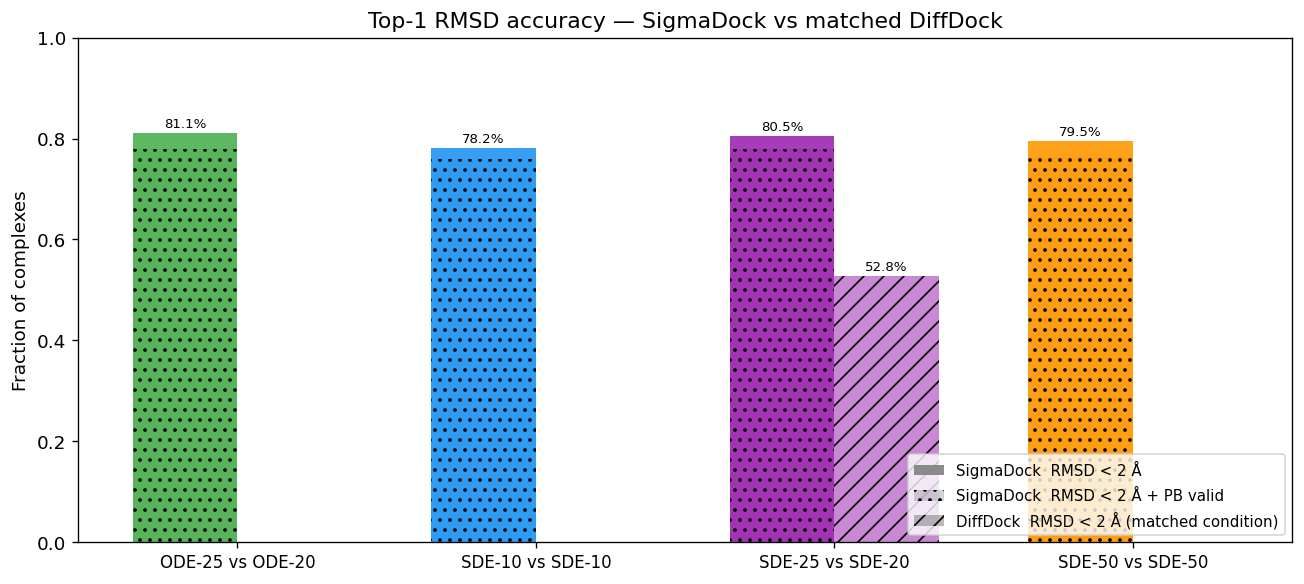

In [5]:
def _accuracy(top1_rmsd, pb_json):
    """Return (rmsd_frac, pb_and_rmsd_frac); pb value is None if pb_json missing."""
    if top1_rmsd is None:
        return None, None
    rmsd_frac = float((top1_rmsd < 2.0).mean())
    if pb_json is None:
        return rmsd_frac, None
    pb_pass = np.array([
        bool(v.get('valid_ranks') and v['valid_ranks'][0] == 'rank1')
        for v in pb_json.values()
    ])
    if len(pb_pass) != len(top1_rmsd):
        return rmsd_frac, None
    return rmsd_frac, float(((top1_rmsd < 2.0) & pb_pass).mean())

conds = list(CONDITIONS.keys())
x     = np.arange(len(conds))
w     = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
for i, cond in enumerate(conds):
    cfg = CONDITIONS[cond]
    sd_r, sd_pb = _accuracy(sd[cond]['top1_rmsd'], sd[cond]['pb_json'])
    dd_r, _     = _accuracy(dd[cond]['top1_rmsd'], None)

    b_sd = ax.bar(x[i] - w/2, sd_r or 0, w, color=cfg['color'], alpha=0.9)
    b_dd = ax.bar(x[i] + w/2, dd_r or 0, w, color=cfg['color'], alpha=0.55, hatch='//')
    if sd_pb is not None:
        ax.bar(x[i] - w/2, sd_pb, w, color=cfg['color'], alpha=0.35, hatch='..')

    for b, v in [(b_sd, sd_r), (b_dd, dd_r)]:
        if v is not None:
            ax.text(b[0].get_x() + b[0].get_width()/2, v + 0.005,
                    f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='grey', alpha=0.9,  label='SigmaDock  RMSD < 2 Å'),
    Patch(facecolor='grey', alpha=0.35, hatch='..', label='SigmaDock  RMSD < 2 Å + PB valid'),
    Patch(facecolor='grey', alpha=0.55, hatch='//', label='DiffDock  RMSD < 2 Å (matched condition)'),
], loc='lower right', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([
    f"ODE-25 vs ODE-20", "SDE-10 vs SDE-10",
    "SDE-25 vs SDE-20", "SDE-50 vs SDE-50"
], fontsize=10)
ax.set_ylabel('Fraction of complexes')
ax.set_ylim(0, 1.0)
ax.set_title('Top-1 RMSD accuracy — SigmaDock vs matched DiffDock')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/top1_rmsd_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Flat TARP — symRMSD K=10 ECP curves

Each panel: one SigmaDock condition (solid) vs DiffDock (dashed red) as reference.
DiffDock uses K=10 if available, otherwise falls back to K=1.

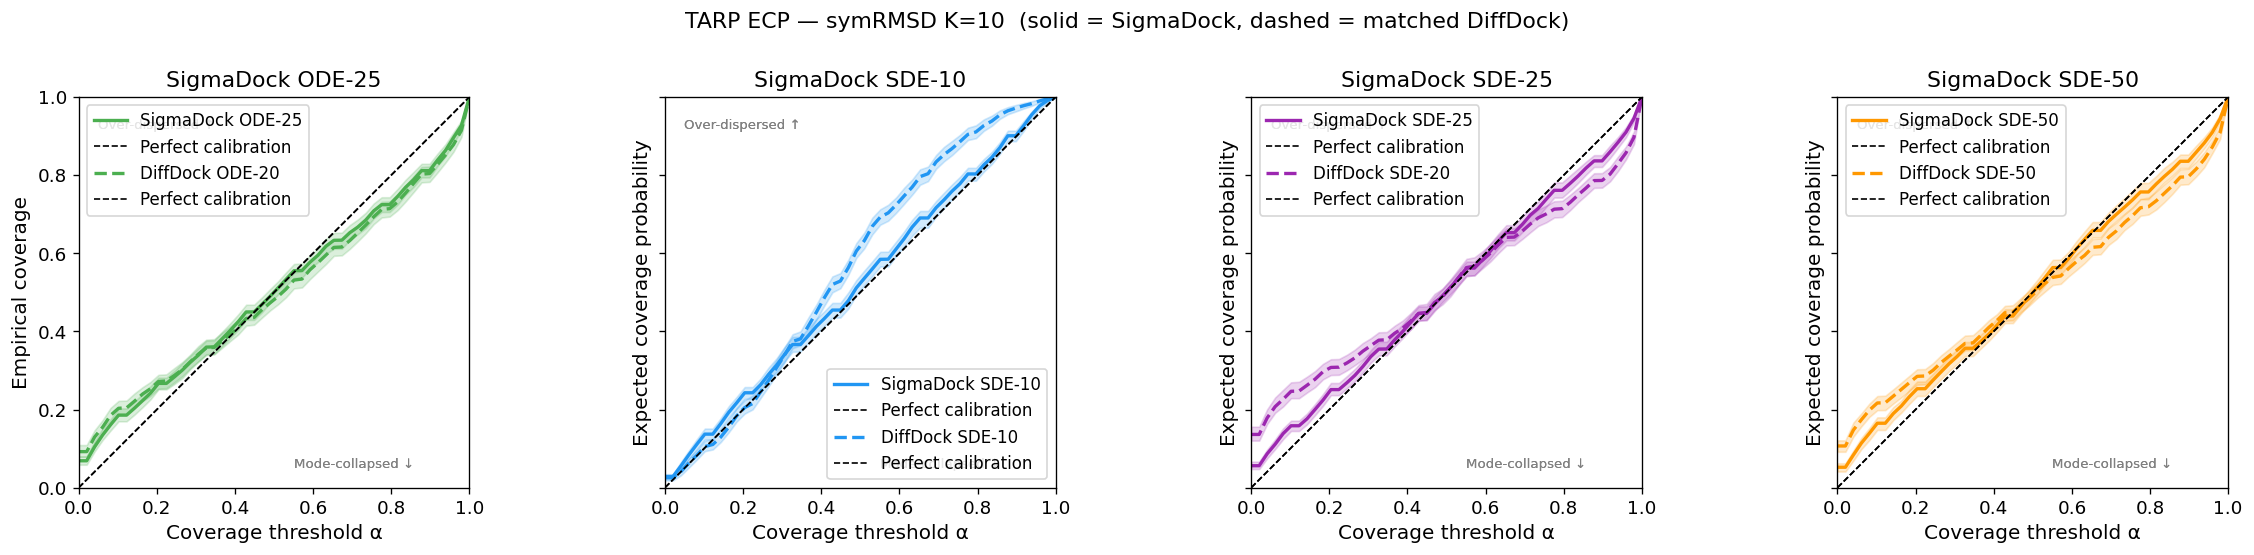

In [6]:
def _ecp_band(ax, fracs, label, color, ls='-', n_boot=N_BOOT):
    if fracs is None:
        return False
    ecp, alpha = ecp_from_fractions(fracs)
    boot = bootstrap_ecp(fracs, n_bootstrap=n_boot)
    plot_ecp(ecp, alpha, ax=ax, label=label, color=color,
             bootstrap_ecps=boot, linestyle=ls)
    return True

conds_ready = [c for c in CONDITIONS if sd[c]['tarp_f'] is not None]
if not conds_ready:
    print('No SigmaDock TARP data yet — run mira_tarp jobs first.')
else:
    ncols = len(conds_ready)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5), sharey=True)
    if ncols == 1:
        axes = [axes]

    for ax, cond in zip(axes, conds_ready):
        cfg = CONDITIONS[cond]
        _ecp_band(ax, sd[cond]['tarp_f'], cfg['label'], cfg['color'])
        dd_tarp = dd[cond]['tarp_f'] if dd[cond]['tarp_f'] is not None else dd[cond].get('tarp_K1')
        _ecp_band(ax, dd_tarp, cfg['dd_label'], cfg['color'], ls=DD_LS)
        ax.set_title(cfg['label'])
        ax.set_xlabel('Coverage threshold α')
        if ax is axes[0]:
            ax.set_ylabel('Empirical coverage')

    fig.suptitle('TARP ECP — symRMSD K=10  (solid = SigmaDock, dashed = matched DiffDock)', y=1.01)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/tarp_ecp_flat.png', dpi=150, bbox_inches='tight')
    plt.show()

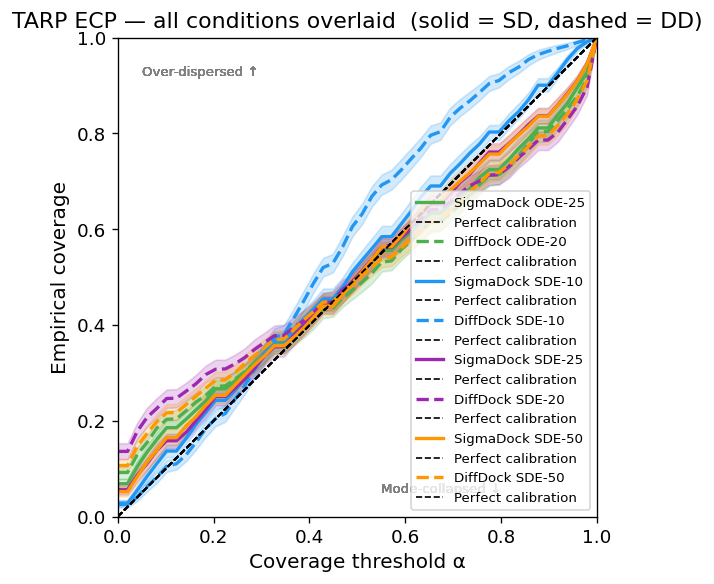

In [7]:
if conds_ready:
    fig, ax = plt.subplots(figsize=(6, 5))
    for cond in conds_ready:
        cfg = CONDITIONS[cond]
        _ecp_band(ax, sd[cond]['tarp_f'], cfg['label'], cfg['color'])
        dd_tarp = dd[cond]['tarp_f'] if dd[cond]['tarp_f'] is not None else dd[cond].get('tarp_K1')
        _ecp_band(ax, dd_tarp, cfg['dd_label'], cfg['color'], ls=DD_LS)
    ax.set_xlabel('Coverage threshold α')
    ax.set_ylabel('Empirical coverage')
    ax.set_title('TARP ECP — all conditions overlaid  (solid = SD, dashed = DD)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/tarp_ecp_flat_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Flat MIRA

Left: violin per model. Right: mean MIRA per condition with ±1σ error bars.
Null reference line at `mira_null(40) ≈ 0.683`.

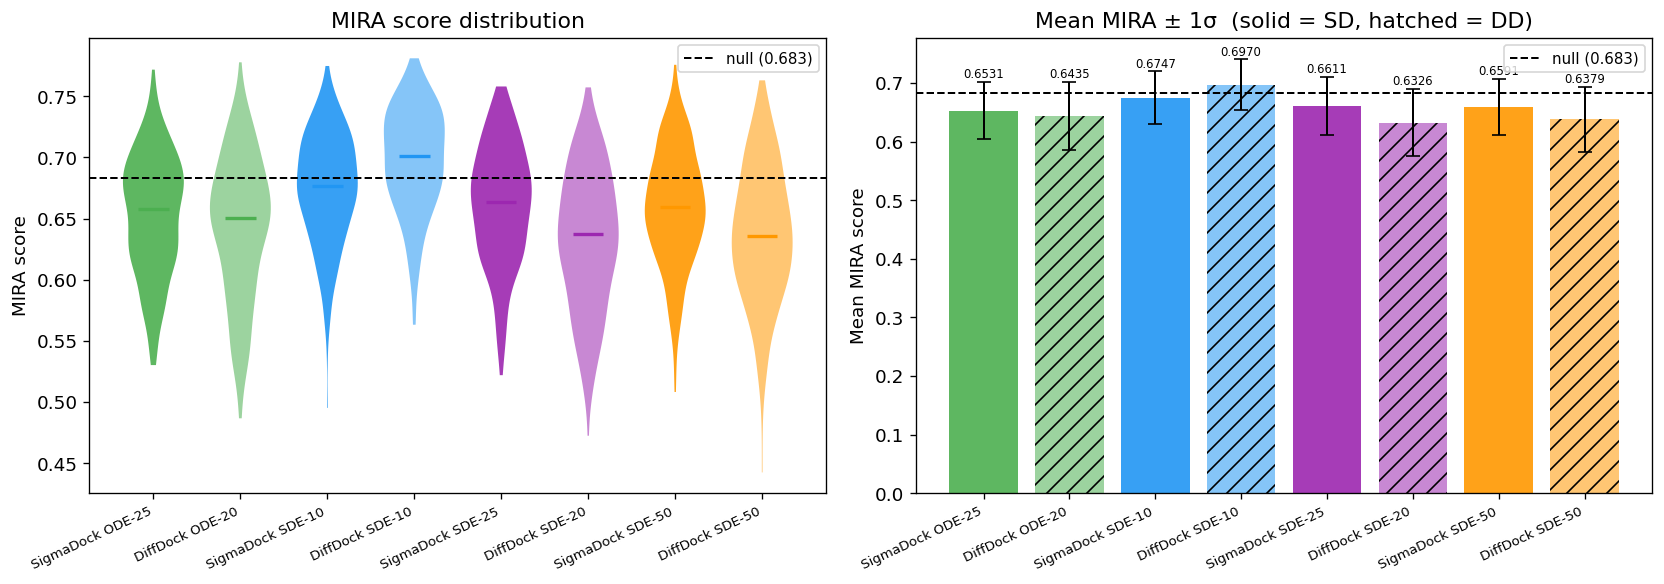

In [8]:
# Interleave SD and DD: SD-ode25, DD-ode20, SD-sde10, DD-sde10, ...
datasets = []
for cond in CONDITIONS:
    cfg = CONDITIONS[cond]
    if sd[cond]['mira_scores'] is not None:
        datasets.append((cfg['label'],    sd[cond]['mira_scores'], cfg['color'], '',   0.9))
    if dd[cond]['mira_scores'] is not None:
        datasets.append((cfg['dd_label'], dd[cond]['mira_scores'], cfg['color'], '//', 0.55))

if not datasets:
    print('No MIRA data yet.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    positions = np.arange(len(datasets))

    # ── Left: violin ──────────────────────────────────────────────────────
    ax = axes[0]
    for pos, (lbl, scores, col, hatch, alpha) in zip(positions, datasets):
        vp = ax.violinplot([scores], positions=[pos], showmedians=True,
                           showextrema=False, widths=0.7)
        vp['bodies'][0].set_facecolor(col)
        vp['bodies'][0].set_alpha(alpha)
        vp['cmedians'].set_color(col)
        vp['cmedians'].set_linewidth(2)
    ax.axhline(MIRA_NULL, color='k', ls='--', lw=1.2, label=f'null ({MIRA_NULL:.3f})')
    ax.set_xticks(positions)
    ax.set_xticklabels([d[0] for d in datasets], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('MIRA score')
    ax.set_title('MIRA score distribution')
    ax.legend(fontsize=9)

    # ── Right: mean ± std ─────────────────────────────────────────────────
    ax = axes[1]
    for pos, (lbl, scores, col, hatch, alpha) in zip(positions, datasets):
        m, s = scores.mean(), scores.std()
        ax.bar(pos, m, color=col, alpha=alpha, hatch=hatch,
               yerr=s, capsize=4, error_kw={'ecolor': 'k', 'lw': 1.2})
        ax.text(pos, m + s + 0.002, f'{m:.4f}', ha='center', va='bottom', fontsize=7)
    ax.axhline(MIRA_NULL, color='k', ls='--', lw=1.2, label=f'null ({MIRA_NULL:.3f})')
    ax.set_xticks(positions)
    ax.set_xticklabels([d[0] for d in datasets], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Mean MIRA score')
    ax.set_title('Mean MIRA ± 1σ  (solid = SD, hatched = DD)')
    ax.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/mira_flat.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Group TARP — symRMSD K=100

One figure per DOF (Translation / Rotation / Torsion).  
Each figure: one panel per SigmaDock condition + one overlay panel.

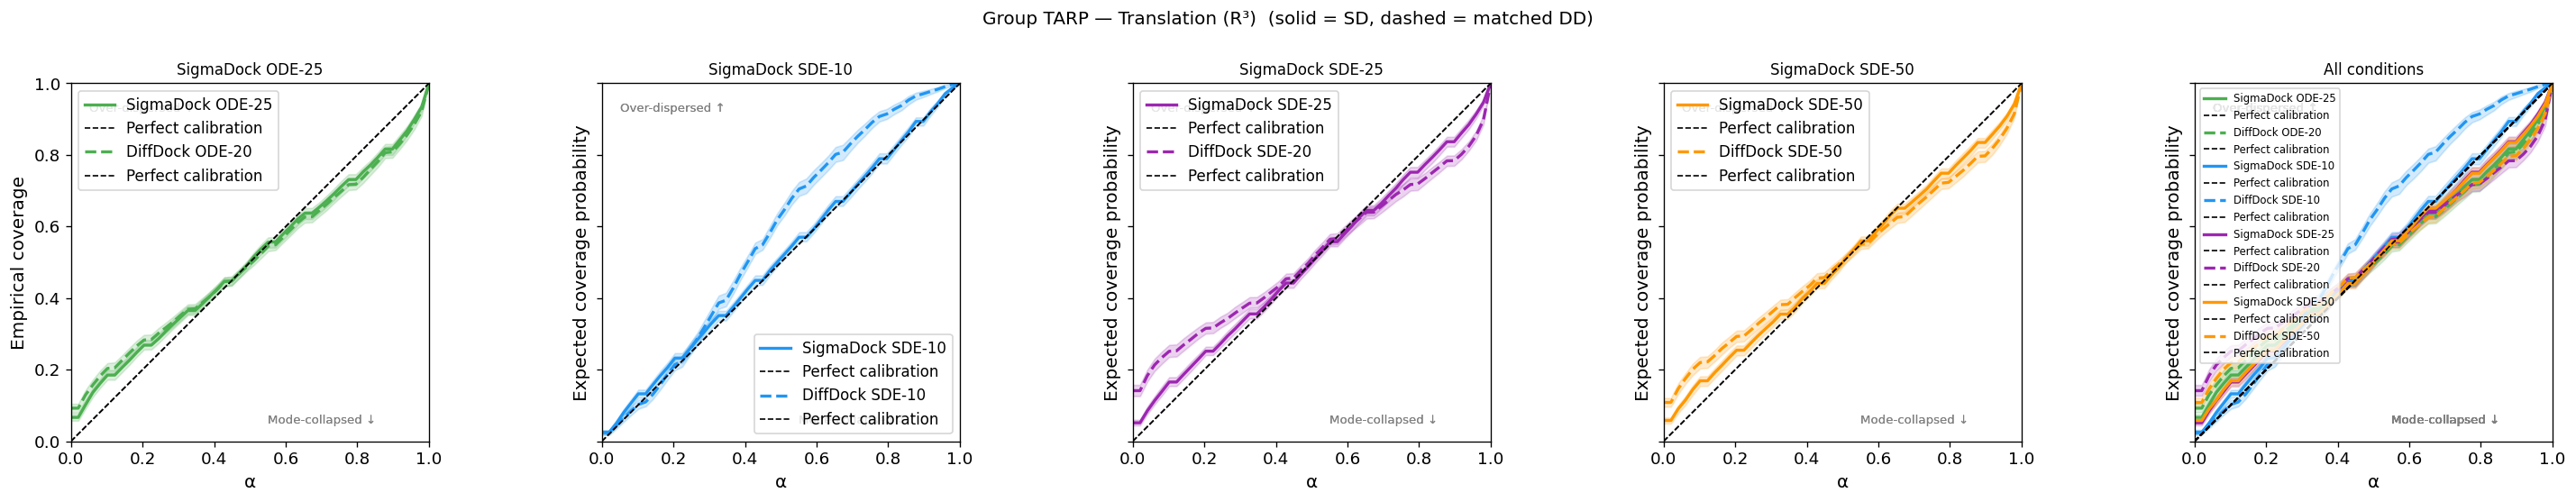

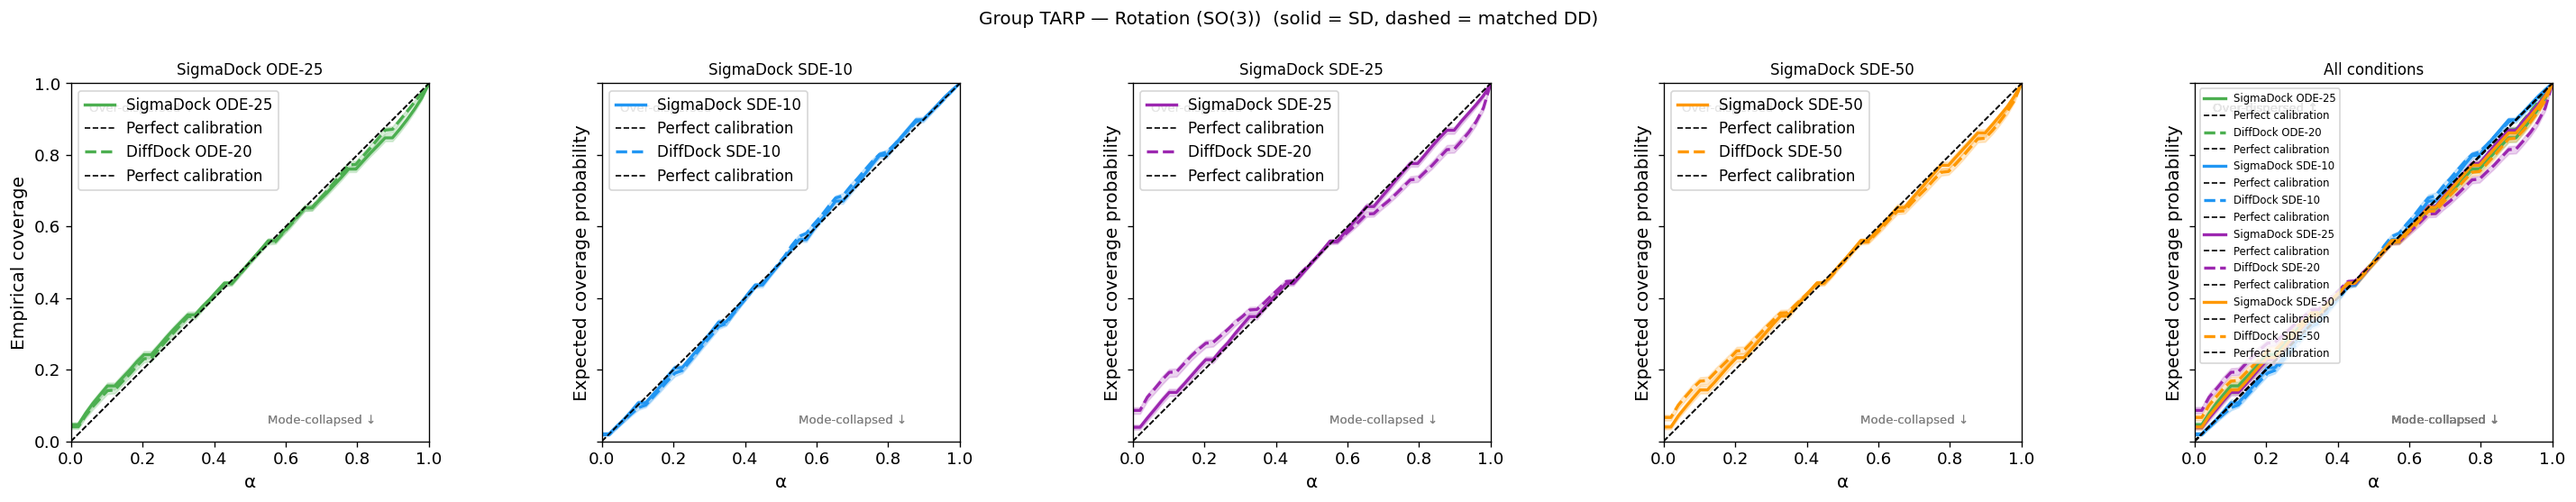

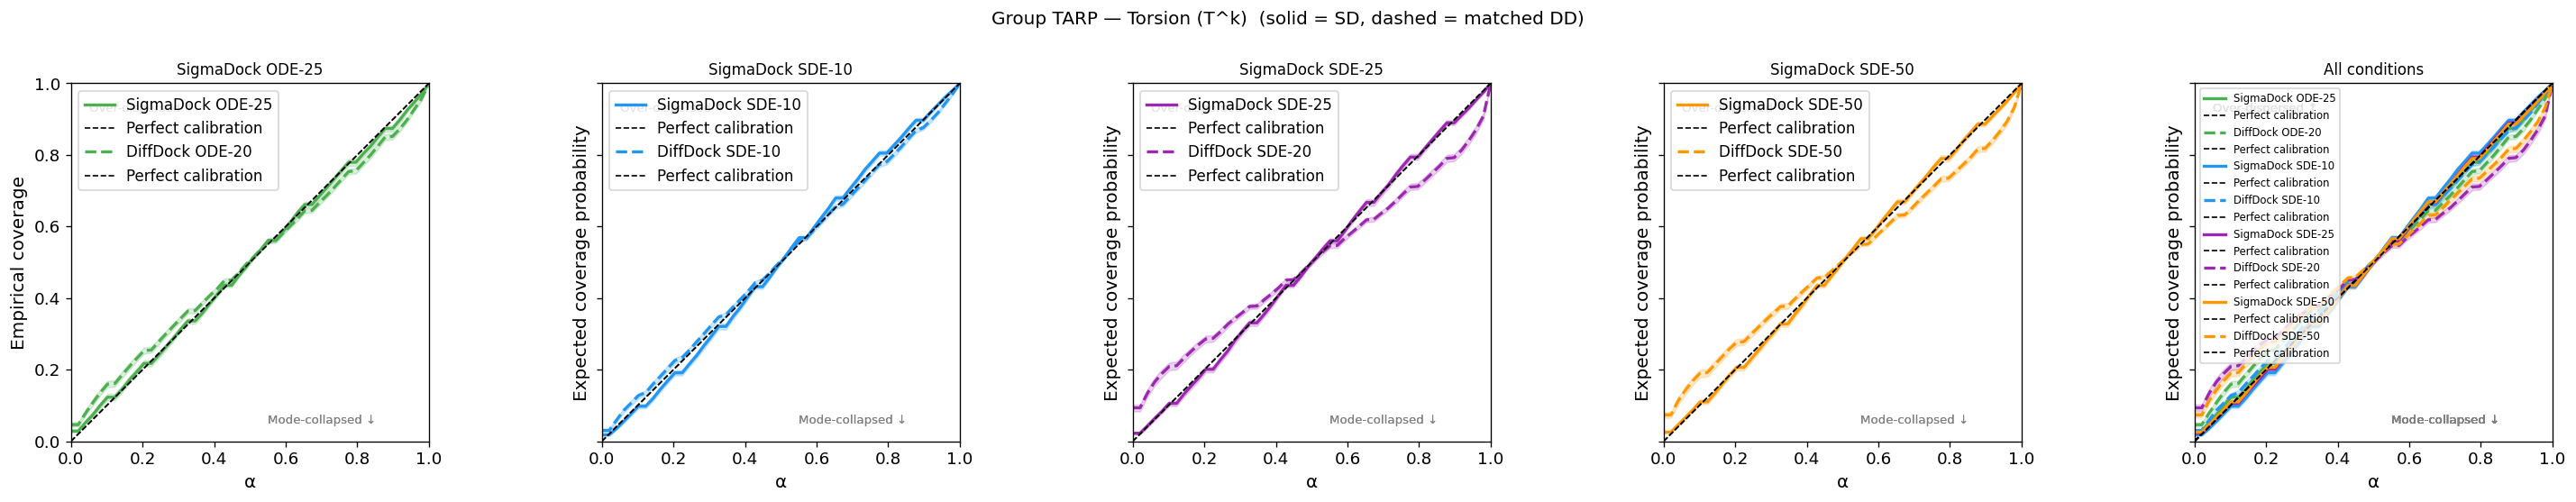

In [9]:
for g in GROUPS:
    conds_g = [c for c in CONDITIONS if sd[c][f'tarp_{g}'] is not None]

    if not conds_g:
        print(f'Group TARP {g}: no data yet.')
        continue

    ncols = len(conds_g) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5), sharey=True)
    if ncols == 1:
        axes = [axes]

    for ax, cond in zip(axes[:-1], conds_g):
        cfg = CONDITIONS[cond]
        _ecp_band(ax, sd[cond][f'tarp_{g}'], cfg['label'], cfg['color'])
        _ecp_band(ax, dd[cond][f'tarp_{g}'], cfg['dd_label'], cfg['color'], ls=DD_LS)
        ax.set_title(cfg['label'], fontsize=10)
        ax.set_xlabel('α')
        if ax is axes[0]:
            ax.set_ylabel('Empirical coverage')

    ax_ov = axes[-1]
    for cond in conds_g:
        cfg = CONDITIONS[cond]
        _ecp_band(ax_ov, sd[cond][f'tarp_{g}'], cfg['label'], cfg['color'])
        _ecp_band(ax_ov, dd[cond][f'tarp_{g}'], cfg['dd_label'], cfg['color'], ls=DD_LS)
    ax_ov.set_title('All conditions', fontsize=10)
    ax_ov.set_xlabel('α')
    ax_ov.legend(fontsize=7, loc='upper left')

    fig.suptitle(f'Group TARP — {GROUP_LABELS[g]}  (solid = SD, dashed = matched DD)', y=1.01, fontsize=12)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/group_tarp_{g}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Group MIRA

Grouped bar chart: x-axis = DOF, bars per model condition + DiffDock.  
Null reference line per panel.

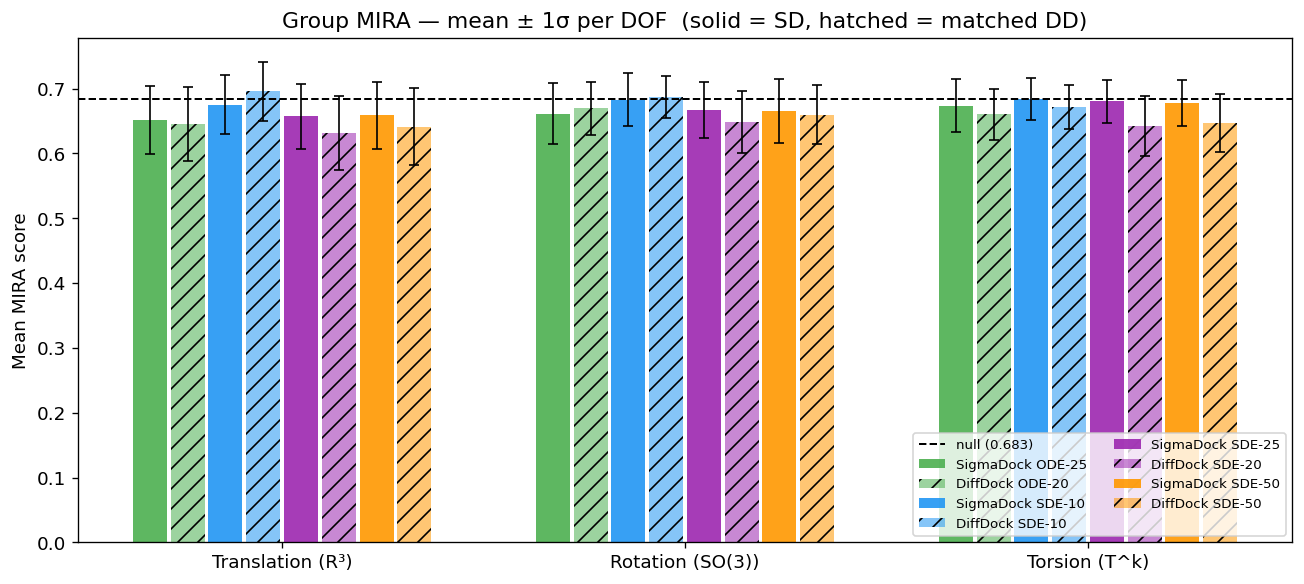

In [10]:
all_models  = list(CONDITIONS.keys())
all_labels  = [CONDITIONS[c]['label']    for c in CONDITIONS]
all_colors  = [CONDITIONS[c]['color']    for c in CONDITIONS]
all_dd_lbls = [CONDITIONS[c]['dd_label'] for c in CONDITIONS]

group_means    = {m: {} for m in all_models}
group_stds     = {m: {} for m in all_models}
group_dd_means = {m: {} for m in all_models}
group_dd_stds  = {m: {} for m in all_models}

for cond in all_models:
    for g in GROUPS:
        arr = sd[cond][f'mira_{g}']
        group_means[cond][g] = arr.mean() if arr is not None else None
        group_stds[cond][g]  = arr.std()  if arr is not None else None
        arr_dd = dd[cond][f'mira_{g}']
        group_dd_means[cond][g] = arr_dd.mean() if arr_dd is not None else None
        group_dd_stds[cond][g]  = arr_dd.std()  if arr_dd is not None else None

any_data = any(group_means[m][g] is not None for m in all_models for g in GROUPS)
if not any_data:
    print('No group MIRA data yet.')
else:
    n_models = len(all_models)
    x = np.arange(len(GROUPS))
    w = 0.75 / (n_models * 2)
    offsets = np.linspace(-(n_models - 0.5) * w, (n_models - 0.5) * w, n_models * 2)

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (model, lbl, dd_lbl, col) in enumerate(zip(all_models, all_labels, all_dd_lbls, all_colors)):
        # SD bars
        sd_means = [group_means[model][g]    for g in GROUPS]
        sd_stds  = [group_stds[model][g]     for g in GROUPS]
        dd_means = [group_dd_means[model][g] for g in GROUPS]
        dd_stds  = [group_dd_stds[model][g]  for g in GROUPS]

        valid_sd = [m is not None for m in sd_means]
        valid_dd = [m is not None for m in dd_means]

        if any(valid_sd):
            ax.bar(x[valid_sd] + offsets[i*2], [m for m, v in zip(sd_means, valid_sd) if v],
                   w * 0.9, color=col, alpha=0.9, label=lbl,
                   yerr=[s for s, v in zip(sd_stds, valid_sd) if v],
                   capsize=3, error_kw={'ecolor': 'k', 'lw': 1})
        if any(valid_dd):
            ax.bar(x[valid_dd] + offsets[i*2+1], [m for m, v in zip(dd_means, valid_dd) if v],
                   w * 0.9, color=col, alpha=0.55, hatch='//', label=dd_lbl,
                   yerr=[s for s, v in zip(dd_stds, valid_dd) if v],
                   capsize=3, error_kw={'ecolor': 'k', 'lw': 1})

    ax.axhline(MIRA_NULL, color='k', ls='--', lw=1.2, label=f'null ({MIRA_NULL:.3f})')
    ax.set_xticks(x)
    ax.set_xticklabels([GROUP_LABELS[g] for g in GROUPS])
    ax.set_ylabel('Mean MIRA score')
    ax.set_title('Group MIRA — mean ± 1σ per DOF  (solid = SD, hatched = matched DD)')
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/group_mira.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Summary table

In [11]:
def _fmt(v, fmt='.4f'):
    return f'{v:{fmt}}' if v is not None else '   –'

HEADER = (f"{'Model':<22}  {'N':>5}  {'RMSD<2Å':>8}  {'MIRA':>8}  "
          f"{'ΔMIRA':>7}  "
          f"{'MIRA_tr':>8}  {'MIRA_rot':>9}  {'MIRA_tor':>9}")
print(HEADER)
print('─' * len(HEADER))

for cond in CONDITIONS:
    cfg = CONDITIONS[cond]
    for label, data in [(cfg['label'], sd[cond]), (cfg['dd_label'], dd[cond])]:
        ms    = data['mira_scores']
        mira  = ms.mean() if ms is not None else None
        delta = (mira - MIRA_NULL) if mira is not None else None
        n     = len(ms) if ms is not None else (len(data['top1_rmsd']) if data['top1_rmsd'] is not None else None)
        rmsd  = float((data['top1_rmsd'] < 2.0).mean()) if data['top1_rmsd'] is not None else None
        m_tr  = data['mira_translation'].mean() if data.get('mira_translation') is not None else None
        m_rot = data['mira_rotation'].mean()    if data.get('mira_rotation')    is not None else None
        m_tor = data['mira_torsion'].mean()     if data.get('mira_torsion')     is not None else None

        print(f"{label:<22}  {str(n) if n else '–':>5}  "
              f"{_fmt(rmsd, '.1%'):>8}  {_fmt(mira):>8}  "
              f"{_fmt(delta,'+.4f'):>7}  "
              f"{_fmt(m_tr):>8}  {_fmt(m_rot):>9}  {_fmt(m_tor):>9}")
    print()

print(f"MIRA null (S=40): {MIRA_NULL:.4f}")

Model                       N   RMSD<2Å      MIRA    ΔMIRA   MIRA_tr   MIRA_rot   MIRA_tor
──────────────────────────────────────────────────────────────────────────────────────────
SigmaDock ODE-25          308     81.1%    0.6531  -0.0302    0.6520     0.6614     0.6739
DiffDock ODE-20           305         –    0.6435  -0.0398    0.6454     0.6694     0.6602

SigmaDock SDE-10          308     78.2%    0.6747  -0.0087    0.6751     0.6831     0.6839
DiffDock SDE-10           305         –    0.6970  +0.0137    0.6961     0.6871     0.6722

SigmaDock SDE-25          308     80.5%    0.6611  -0.0222    0.6575     0.6675     0.6802
DiffDock SDE-20           305     52.8%    0.6326  -0.0507    0.6315     0.6485     0.6423

SigmaDock SDE-50          308     79.5%    0.6591  -0.0243    0.6588     0.6659     0.6779
DiffDock SDE-50           305         –    0.6379  -0.0454    0.6415     0.6598     0.6476

MIRA null (S=40): 0.6833
